# anime_dataset.py使用示例

In [1]:
from anime_dataset import AnimePoseDataset, DatasetConfig, AnimeSkeletonData, AnimeView, AnimeModel
from face5_provider import Face5Provider
from pathlib import Path
import os
from tqdm import tqdm

In [2]:
TEST_WORK_SPACE = Path("./test_workspace")
os.makedirs(TEST_WORK_SPACE, exist_ok=True)

## 初始化整个dataset
实例化一个`AniPoseDataset`对象。

In [3]:
dataset = AnimePoseDataset(
    root=Path("./link-to-anime"),
    config=DatasetConfig(frames_per_view=72)
)

- `model`: 从当前数据集的测试集里获取`/68 model`人物模型目录.你将获取一个被实例化的`AnimeModel`对象。
- `view`: 从当前人物模型目录实例(它是一个的`AnimeModel`对象)中获得view目录对象
-  `sample_frame`: 帧实例，是一个   对象。获得对应帧，以及相应信息。

In [4]:
model = dataset.get_model("test", "color_line_optic_68_80", "68 model")
view = model.get_view("01 visual_view")
sample_frame = view.get_frame(1)

print(sample_frame.uuid)
print(sample_frame.image_path)
print(sample_frame.bbox)
print(sample_frame.keypoints)

[DEBUG] checking split_dir: link-to-anime/train
[DEBUG] checking model_dir: link-to-anime/train/color_line_optic_01_25/01 model
[DEBUG] checking model_dir: link-to-anime/train/color_line_optic_26_45/26 model
[DEBUG] checking split_dir: link-to-anime/val
[DEBUG] checking split_dir: link-to-anime/test
[DEBUG] checking model_dir: link-to-anime/test/color_line_optic_68_80/68 model
6b7b5ac6-dc8a-51b7-96b4-973cc20b5c02
test/color_line_optic_68_80/68 model/01 visual_view/01_1 Rendering/0001_1.png
[810, 389, 707, 1051]
{'mixamorig:Hips': {'x': 1323.811339260895, 'y': 1202.4335864545471, 'z': 0.0, 'visibility': 0}, 'mixamorig:Spine': {'x': 1323.409009976397, 'y': 1119.3550097142381, 'z': 0.0, 'visibility': 0}, 'mixamorig:Spine1': {'x': 1319.3719414264951, 'y': 1022.2344482724927, 'z': 0.0, 'visibility': 0}, 'mixamorig:Spine2': {'x': 1312.2124161969236, 'y': 911.1976361726298, 'z': 0.0, 'visibility': 0}, 'mixamorig:Neck': {'x': 1301.4043689526038, 'y': 785.9025245588372, 'z': 0.0, 'visibility': 

## 保存原始数据json
- mixamo特征点
- bbox
- 渲染图路径
- 其它元数据

In [5]:
sample_frame.save_json(TEST_WORK_SPACE / "sample_frame_1.json")

### 批量导出
- 位于每个人物模型目录下`exported_data`
- 每个view一个子目录，每个frame对应一个json

In [6]:
 
def export_all_frames(dataset: AnimePoseDataset, 
                      out_root: Path = None  # TODO: 支持自定义输出根目录
                      
                      ):
    _export_errors = []

    for model in tqdm(list(dataset.iter_models()), desc="models"):
        for view in model.iter_views():

            # ── view 目录检查 
            if not Path(view.view_path).exists():
                print(f"[WARNING] view 目录不存在，跳过整个 model: {view.view_path}")
                break   # 跳过这个 model 剩余的所有 view

            # output dir(view)
            view.json_out_dir = Path(model.model_path) / "exported_data" / view.view_name
            view.json_out_dir.mkdir(parents=True, exist_ok=True)
            try:
                for frame in view.iter_frames():

                    # ── 图像文件检查
                    abs_img = Path(dataset.root) / frame.image_path
                    if not abs_img.exists():
                        print(f"[WARNING] 图像不存在，跳过该帧: {abs_img}")
                        _export_errors.append(str(abs_img))
                        continue

                    # ── 写 JSON 
                    frame.json_out_path = view.json_out_dir / f"frame_{frame.frame_id:04d}.json"
                    try:
                        frame.save_json(frame.json_out_path)
                    except Exception as e:
                        print(f"[ERROR] save_json 失败: {frame.json_out_path}\n  {e}")
                        _export_errors.append(str(frame.json_out_path))
            except Exception as e:
                print(f"[ERROR] 处理view 失败 or view files does not exist，跳过剩余帧: {view.view_path}\n  {e}")
                _export_errors.append(str(view.view_path))

    print(f"\n✓ 导出完成。失败帧数: {len(_export_errors)}")
    if _export_errors:
        print("失败列表：")
        for p in _export_errors:
            print(f"  {p}")

In [7]:
export_all_frames(dataset)


models:   0%|          | 0/3 [00:00<?, ?it/s]

[ERROR] 处理view 失败 or view files does not exist，跳过剩余帧: link-to-anime/train/color_line_optic_01_25/01 model/01 visual_view
  [Errno 2] No such file or directory: 'link-to-anime/train/color_line_optic_01_25/01 model/01 visual_view/01_1 Rendering'
[ERROR] 处理view 失败 or view files does not exist，跳过剩余帧: link-to-anime/train/color_line_optic_01_25/01 model/02 visual_view
  [Errno 2] No such file or directory: 'link-to-anime/train/color_line_optic_01_25/01 model/02 visual_view/02_1 Rendering'
[ERROR] 处理view 失败 or view files does not exist，跳过剩余帧: link-to-anime/train/color_line_optic_01_25/01 model/03 visual_view
  [Errno 2] No such file or directory: 'link-to-anime/train/color_line_optic_01_25/01 model/03 visual_view/03_1 Rendering'
[ERROR] 处理view 失败 or view files does not exist，跳过剩余帧: link-to-anime/train/color_line_optic_01_25/01 model/04 visual_view
  [Errno 2] No such file or directory: 'link-to-anime/train/color_line_optic_01_25/01 model/04 visual_view/04_1 Rendering'
[ERROR] 处理view 失败 or vie

models: 100%|██████████| 3/3 [00:01<00:00,  2.35it/s]


✓ 导出完成。失败帧数: 5
失败列表：
  link-to-anime/train/color_line_optic_01_25/01 model/01 visual_view
  link-to-anime/train/color_line_optic_01_25/01 model/02 visual_view
  link-to-anime/train/color_line_optic_01_25/01 model/03 visual_view
  link-to-anime/train/color_line_optic_01_25/01 model/04 visual_view
  link-to-anime/train/color_line_optic_01_25/01 model/05 visual_view


## 转换为coco17
- 推理出五个缺失的面部特征点
- 转换为coco17格式

- 实例化一个Face5推理器`provider`
- 推理，并用推理出的5个点把姿态特征点扩张、编辑到coco17标准。
- 转换后的`coco_sample_frame`也是一个` AnimeSkeletonData`实例。

In [8]:
provider = Face5Provider(device="cuda", backend="onnxruntime")


coco_sample_frame: AnimeSkeletonData = sample_frame.to_coco17(strict=True, face5_provider=provider, dataset_root=dataset.root)


coco_sample_frame.face5_info   # "inferred" 或 "Head out of frame" 等


2026-03-30 02:09:32.207877360 [W:onnxruntime:, session_state.cc:1327 VerifyEachNodeIsAssignedToAnEp] Some nodes were not assigned to the preferred execution providers which may or may not have an negative impact on performance. e.g. ORT explicitly assigns shape related ops to CPU to improve perf.
2026-03-30 02:09:32.207900114 [W:onnxruntime:, session_state.cc:1329 VerifyEachNodeIsAssignedToAnEp] Rerunning with verbose output on a non-minimal build will show node assignments.


load /home/tvem/.cache/rtmlib/hub/checkpoints/yolox_m_8xb8-300e_humanart-c2c7a14a.onnx with onnxruntime backend
load /home/tvem/.cache/rtmlib/hub/checkpoints/rtmw-dw-x-l_simcc-cocktail14_270e-384x288_20231122.onnx with onnxruntime backend


2026-03-30 02:09:32.386142605 [W:onnxruntime:, graph.cc:5241 CleanUnusedInitializersAndNodeArgs] Removing initializer '1701'. It is not used by any node and should be removed from the model.
2026-03-30 02:09:32.386160416 [W:onnxruntime:, graph.cc:5241 CleanUnusedInitializersAndNodeArgs] Removing initializer '1706'. It is not used by any node and should be removed from the model.
2026-03-30 02:09:32.386181118 [W:onnxruntime:, graph.cc:5241 CleanUnusedInitializersAndNodeArgs] Removing initializer '1709'. It is not used by any node and should be removed from the model.
2026-03-30 02:09:32.467561485 [W:onnxruntime:, session_state.cc:1327 VerifyEachNodeIsAssignedToAnEp] Some nodes were not assigned to the preferred execution providers which may or may not have an negative impact on performance. e.g. ORT explicitly assigns shape related ops to CPU to improve perf.
2026-03-30 02:09:32.467577189 [W:onnxruntime:, session_state.cc:1329 VerifyEachNodeIsAssignedToAnEp] Rerunning with verbose outpu

'inferred'

In [9]:
coco_sample_frame.save_json(TEST_WORK_SPACE / "coco_sample_frame_1.json")

预览 AnimeSkeletonData 的关键点（支持 mixamo / coco17） ─

In [10]:
FACE5_NAMES = ["nose", "left_eye", "right_eye", "left_ear", "right_ear"]

预览`coco_sample_frame`的各个姿态特征点情况

[DEBUG] sample.uuid       = 6b7b5ac6-dc8a-51b7-96b4-973cc20b5c02
[DEBUG] sample.sample_key = test/color_line_optic_68_80/68 model/01 visual_view/frame_0001
[DEBUG] sample.format     = coco17
[DEBUG] sample.image_path = test/color_line_optic_68_80/68 model/01 visual_view/01_1 Rendering/0001_1.png
[DEBUG] abs_img_path      = link-to-anime/test/color_line_optic_68_80/68 model/01 visual_view/01_1 Rendering/0001_1.png


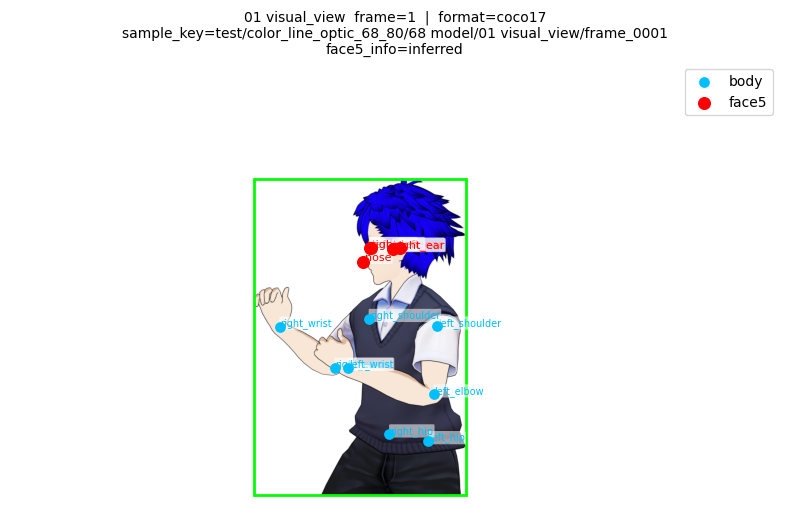

[preview_keypoints] pose_format     : coco17
[preview_keypoints] total keypoints : 17
[preview_keypoints] visible         : 13
[preview_keypoints] face5_info      : inferred


In [11]:
from visualize import  preview_keypoints


preview_keypoints(
    frame_data_instance=coco_sample_frame,
    dataset_root=dataset.root,
    show_labels=True,
    show_invisible=False,
    debug=True,
)

### 批量转换
- 导出在每个人物模型目录下的`export_coco17`下
- 和前面一样，每个view一个子目录(`coco_json_json_out_dir`)，每个frame对应一个json(`coco_json_out_path`)

In [12]:
# ── 单元格2：批量转换 mixamo JSON → coco17 JSON ───────────────────────────────
# 输入：view.iter_frames() 的每一帧（pose_format="mixamo"）
# 输出路径：{model.model_path}/exported_coco17/{view.view_name}/frame_{id:04d}_coco17.json
# 依赖：provider 已在上方单元格初始化

from pathlib import Path
from tqdm.auto import tqdm

_coco_errors = []

for model in tqdm(list(dataset.iter_models()), desc="models"):
    for view in model.iter_views():

        # ── view 目录检查 ──────────────────────────────────────────────────
        if not Path(view.view_path).exists():
            print(f"[WARNING] view 目录不存在，跳过整个 model: {view.view_path}")
            break

        # ── 输出目录（与 exported_data 平级）─────────────────────────────
        view.coco_json_out_dir = Path(model.model_path) / "exported_coco17" / view.view_name  # 在人物模型目录下，新建导出json的目录；该目录下每个 view 输出到一个单独的文件夹
        view.coco_json_out_dir.mkdir(parents=True, exist_ok=True)
        try:
            for frame in view.iter_frames():

                # ── 图像文件检查 ───────────────────────────────────────────────
                abs_img = Path(dataset.root) / frame.image_path
                if not abs_img.exists():
                    print(f"[WARNING] 图像不存在，跳过该帧: {abs_img}")
                    _coco_errors.append(str(abs_img))
                    continue

                # ── 转换 
                frame.coco_json_out_path = view.coco_json_out_dir / f"frame_{frame.frame_id:04d}_coco17.json"
                try:
                    coco_frame = frame.to_coco17(
                        strict=True,
                        face5_provider=provider,
                        dataset_root=dataset.root,
                    )
                    coco_frame.save_json(frame.coco_json_out_path)
                except Exception as e:
                    print(f"[ERROR] 转换失败: {frame.coco_json_out_path}\n  {e}")
                    _coco_errors.append(str(frame.coco_json_out_path))
        except Exception as e:
            print(f"[ERROR] 处理view 失败 or view files does not exist，跳过剩余帧: {view.view_path}\n  {e}")
            _coco_errors.append(str(view.view_path))

print(f"\n✓ 转换完成。失败帧数: {len(_coco_errors)}")
if _coco_errors:
    print("失败列表：")
    for p in _coco_errors:
        print(f"  {p}")

models:   0%|          | 0/3 [00:00<?, ?it/s]

[ERROR] 处理view 失败 or view files does not exist，跳过剩余帧: link-to-anime/train/color_line_optic_01_25/01 model/01 visual_view
  [Errno 2] No such file or directory: 'link-to-anime/train/color_line_optic_01_25/01 model/01 visual_view/01_1 Rendering'
[ERROR] 处理view 失败 or view files does not exist，跳过剩余帧: link-to-anime/train/color_line_optic_01_25/01 model/02 visual_view
  [Errno 2] No such file or directory: 'link-to-anime/train/color_line_optic_01_25/01 model/02 visual_view/02_1 Rendering'
[ERROR] 处理view 失败 or view files does not exist，跳过剩余帧: link-to-anime/train/color_line_optic_01_25/01 model/03 visual_view
  [Errno 2] No such file or directory: 'link-to-anime/train/color_line_optic_01_25/01 model/03 visual_view/03_1 Rendering'
[ERROR] 处理view 失败 or view files does not exist，跳过剩余帧: link-to-anime/train/color_line_optic_01_25/01 model/04 visual_view
  [Errno 2] No such file or directory: 'link-to-anime/train/color_line_optic_01_25/01 model/04 visual_view/04_1 Rendering'
[ERROR] 处理view 失败 or vie

##  交互式骨骼可视化

In [13]:
from visualize import show_skeleton_widget
show_skeleton_widget(dataset)

Output()

## 检查view和某一特定帧的json路径

In [ ]:
FRAME_INDEX = 0


# 诊断单元格
mdl = list(dataset.iter_models())[1]
view = list(mdl.iter_views())[1]

print(f"view.view_name         = {view.view_name}")
print(f"view.coco_json_out_dir = {view.coco_json_out_dir}")

frames = list(view.iter_frames())
f = frames[FRAME_INDEX]  
print(f"\nframe.frame_id           = {f.frame_id}")
print(f"frame.coco_json_out_path = {f.coco_json_out_path}")
print(f"frame.json_out_path      = {f.json_out_path}")

view.view_name         = 02 visual_view
view.coco_json_out_dir = link-to-anime/train/color_line_optic_26_45/26 model/exported_coco17/02 visual_view

frame.frame_id           = 4
frame.coco_json_out_path = link-to-anime/train/color_line_optic_26_45/26 model/exported_coco17/02 visual_view/frame_0004_coco17.json
frame.json_out_path      = link-to-anime/train/color_line_optic_26_45/26 model/exported_data/02 visual_view/frame_0004.json
